In [1]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
import astropy
from astropy.cosmology import Planck15
import astropy.cosmology as cosmo
import astropy.units as u
from scipy.optimize import minimize
from multiprocessing import Pool, Process
import corner
from IPython.display import display, Math
import pickle
import dill
import seaborn as sns
from emcee.moves import StretchMove, WalkMove
%run /home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/wcdm_expansions.ipynb

In [2]:
H0 =  73.5
Om = 0.334
Ok = 0.0
w = -1.0

N=1000
zs = np.linspace(0.01, 5, 1000)

my_cosmo = cosmo.wCDM(H0=H0, Om0=Om, Ode0=1.0-Om-Ok)
dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value
dls_true *= (1 + np.random.normal(0, 0.06, N))
ys = zs/(1+zs)

In [3]:
import os

# Define the directory path where you want to save the files
directory = "/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/Pantheon_without_H0_witscatter"

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Now you can save files inside this directory
file_path = os.path.join(directory, "filename.txt")

# Example: saving some data to the file
with open(file_path, "w") as file:
    file.write("This is some data")

In [4]:
H0t, q0t, j0t, s0t, c0t, p0t = to_cosmographic(H0, Om, Ok, w)
thetat = q0t, j0t, s0t, c0t, p0t
thetat

(-0.4989999999999999,
 1.0,
 -0.5030000000000019,
 3.508006000000009,
 -13.29954500599996)

In [5]:
# import pandas lib as pd
import pandas as pd

# Load the Excel file
dataframe1 = pd.read_excel('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/pantheon_plus.xlsx', usecols=[0,1,2,3,4], skiprows=0)

# Print the DataFrame to check column names
print(dataframe1.head())
print(dataframe1.columns)

# Access columns (replace 'z' and 'magnitude' with actual column names)
z_pantheon = np.array(dataframe1['zCMB'])
mu = np.array(dataframe1['MU_SH0ES'])#m_b_corr'])
err_mu = np.array(dataframe1['MU_SH0ES_ERR_DIAG'])#m_b_corr_err_DIAG'])#

dl_pantheon = 10**(mu/5 -5)
dl_err = dl_pantheon * err_mu * np.log(10)/5
dl_pantheon_mock = my_cosmo.luminosity_distance(z_pantheon).to(u.Mpc).value*( 1 + np.random.normal(0, 0.07, len(z_pantheon)))

      zCMB  MU_SH0ES_ERR_DIAG  MU_SH0ES  m_b_corr  m_b_corr_err_DIAG
0  0.00122           1.516450   28.9987   9.74571           1.516210
1  0.00122           1.517470   29.0559   9.80286           1.517230
2  0.00256           0.782372   30.7233  11.47030           0.781906
3  0.00256           0.799068   30.7449  11.49190           0.798612
4  0.00299           0.881212   30.7757  11.52270           0.880798
Index(['zCMB', 'MU_SH0ES_ERR_DIAG', 'MU_SH0ES', 'm_b_corr',
       'm_b_corr_err_DIAG'],
      dtype='object')


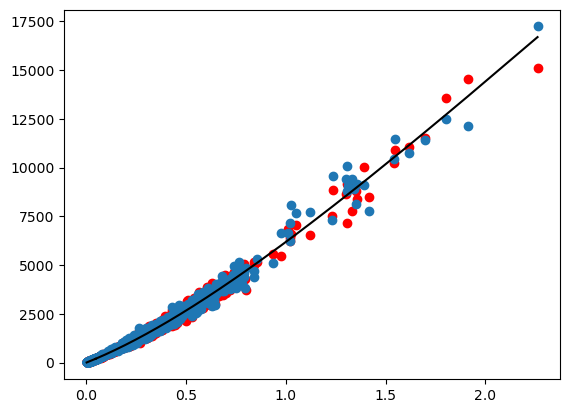

In [6]:
plt.scatter(z_pantheon,dl_pantheon_mock, color = 'red')
plt.scatter(z_pantheon,dl_pantheon)
plt.plot(z_pantheon,log_series(np.log(1+z_pantheon), H0t, q0t, j0t, s0t, c0t, p0t, order=4), color='black')

In [7]:
# FIXED H0

def sigma_dl(dL):    
    sigma_dl = dL * 0.22 * np.log(10)/5
    return sigma_dl

def chi_square(params, H0, func, z, data, orderd):
    sigma = sigma_dl(data)
    diff2 = (func(z, H0, *params, order=orderd) - data)**2
    chi = np.sum(diff2/(sigma**2))
    #print(H0)
    return chi

def log_prior(theta, order):
    if order == 3:
        q0, j0 = theta[:2]
        if -1 < q0 < 1 and -2 < j0 < 3.5:
            return 0.0
        else:
            return -np.inf
    elif order == 4:
        q0, j0, s0 = theta[:3]
        if -1 < q0 < 1 and -2 < j0 < 3.5 and -10 < s0 < 10:
            return 0.0
        else:
            return -np.inf
    elif order == 5:
        q0, j0, s0, c0 = theta[:4]
        if -1 < q0 < 1 and -2 < j0 < 3.5 and -10 < s0 < 10 and -10 < c0 < 25:
            return 0.0
        else:
            return -np.inf
    elif order == 6:
        q0, j0, s0, c0, p0 = theta[:5]
        if -1 < q0 < 1 and -2 < j0 < 3.5 and -10 < s0 < 10 and -10 < c0 < 25 and -45 < p0 < 5:
            return 0.0
        else:
            return -np.inf
    else:
        return -np.inf


def log_posterior(theta, H0, func, z, data, order):
    lp = log_prior(theta, order)
    if not np.isfinite(lp):
        return -np.inf
    else:
        chi2 = chi_square(theta, H0, func, z, data, order)
        return lp - 0.5 * chi2

# MCMC pra cade serie

In [ ]:
filename = "MCMC_pade22_series.png"
file_path = os.path.join(directory, filename)

plt.savefig(file_path, dpi=500, bbox_inches='tight')

<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_139244/1957457382.py:55: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
100%|█████████████████████████████████████| 60000/60000 [23:36<00:00, 42.35it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

100%|█████████████████████████████████████| 90000/90000 [52:20<00:00, 28.66it/s]


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

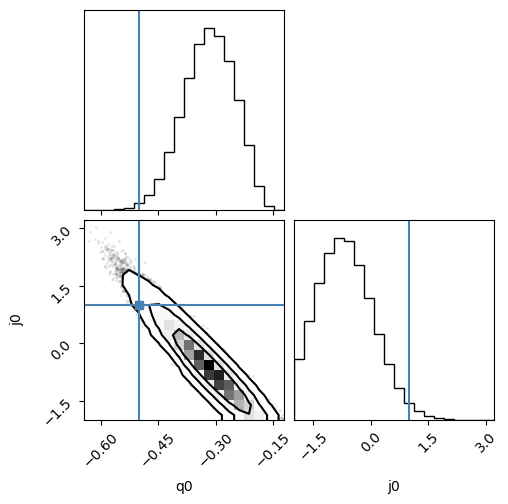

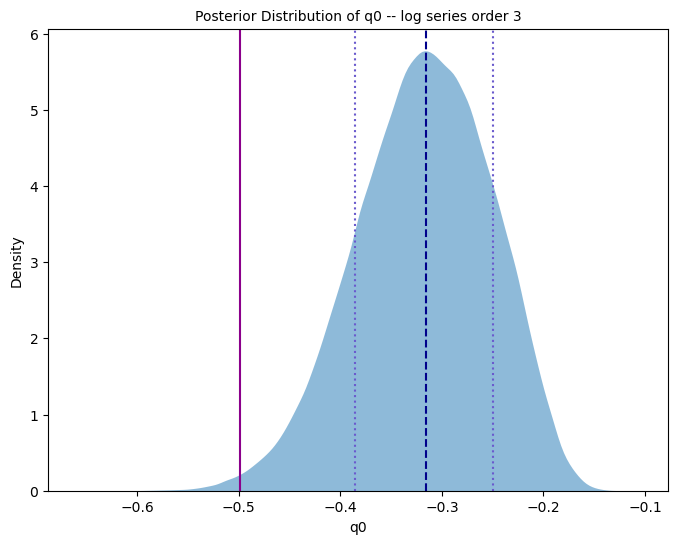

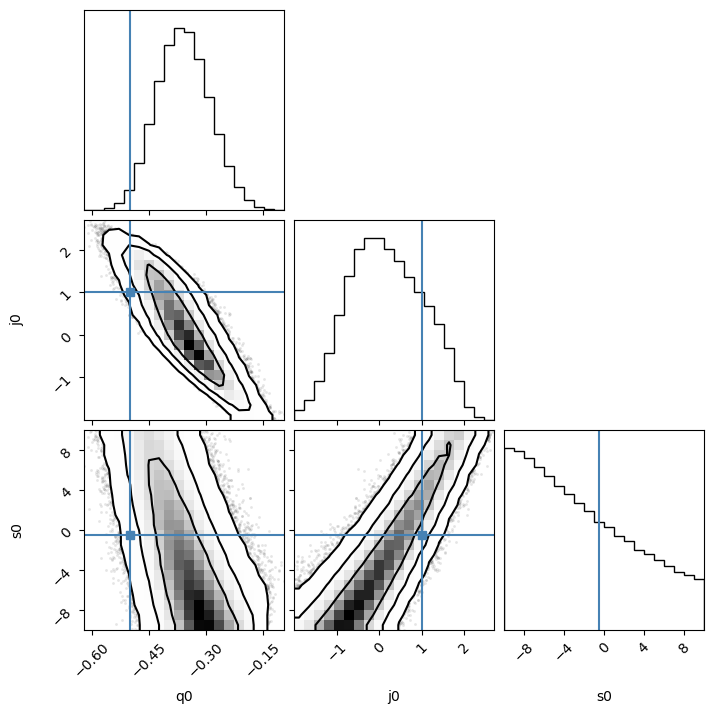

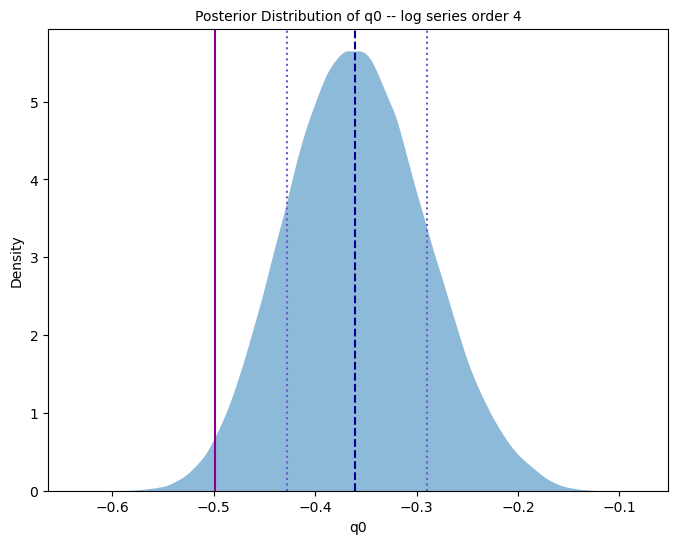

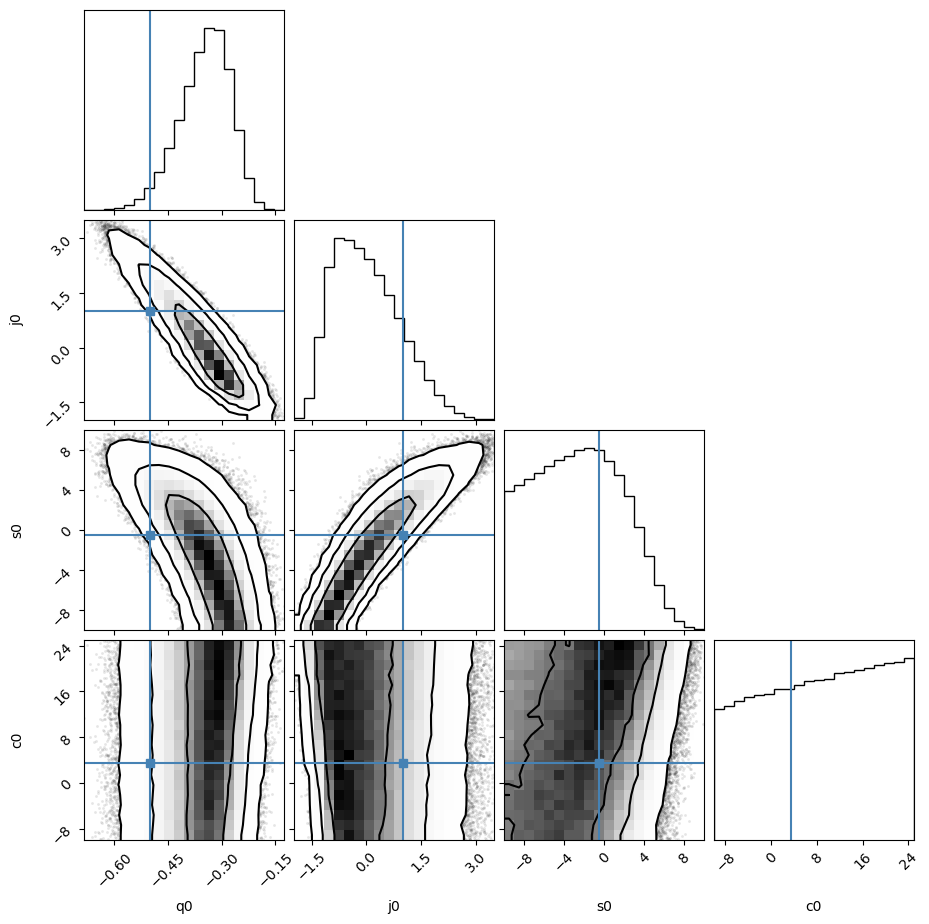

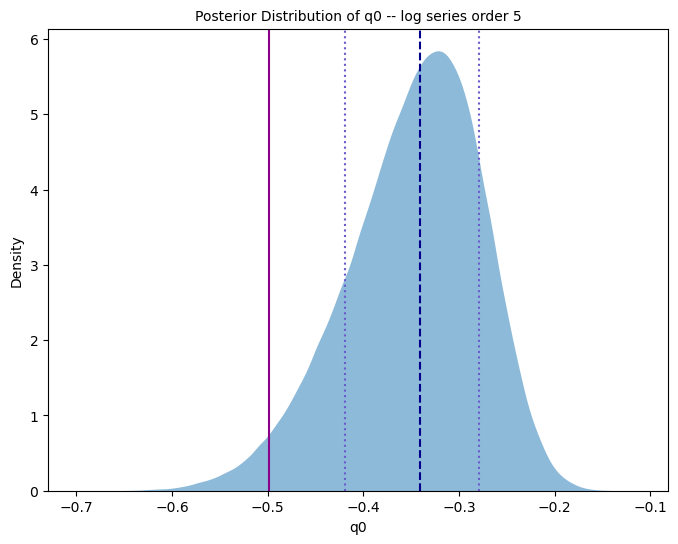

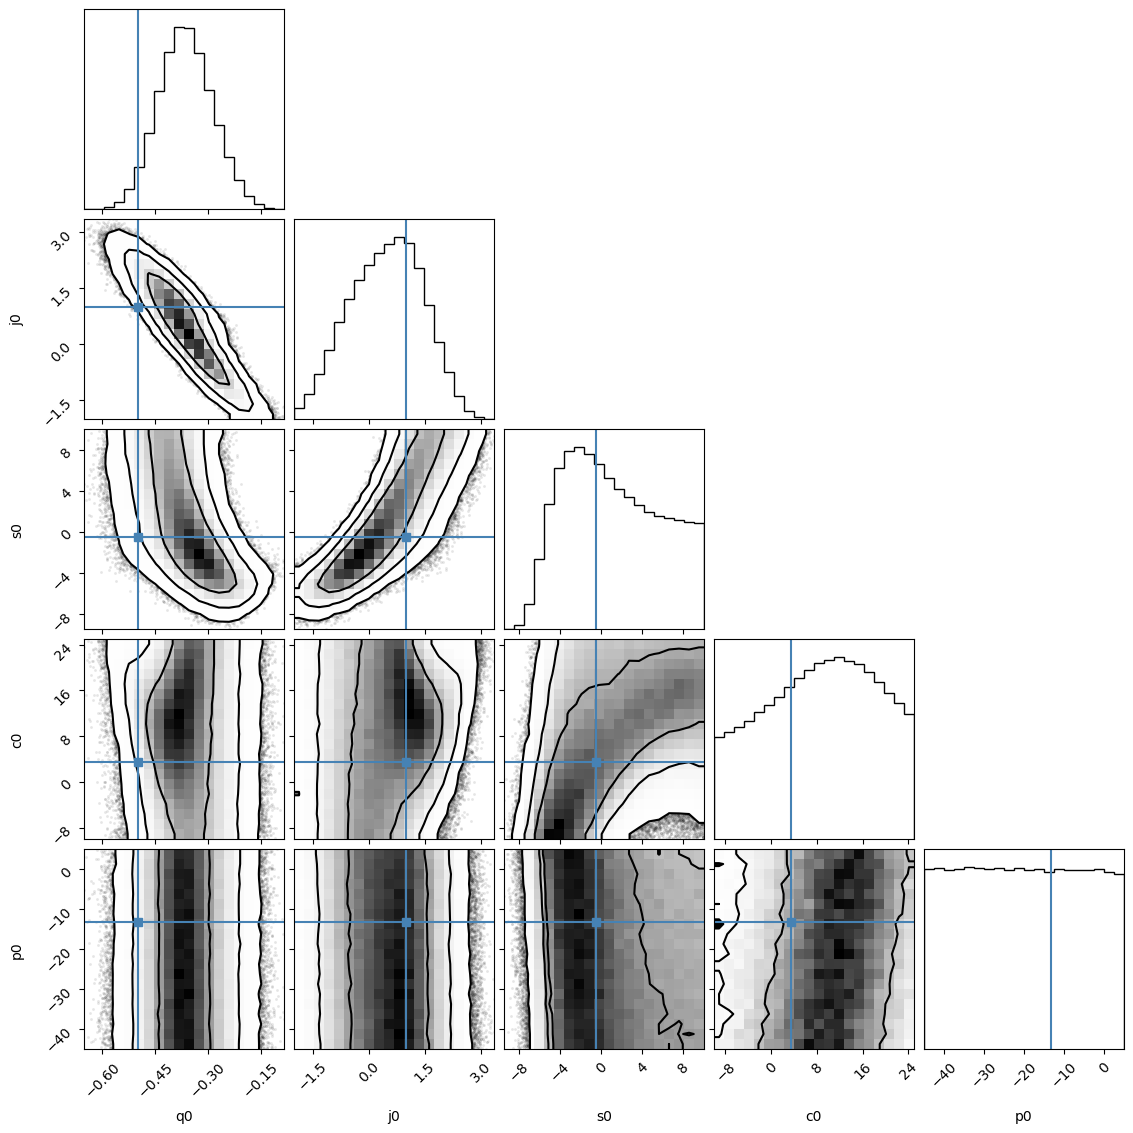

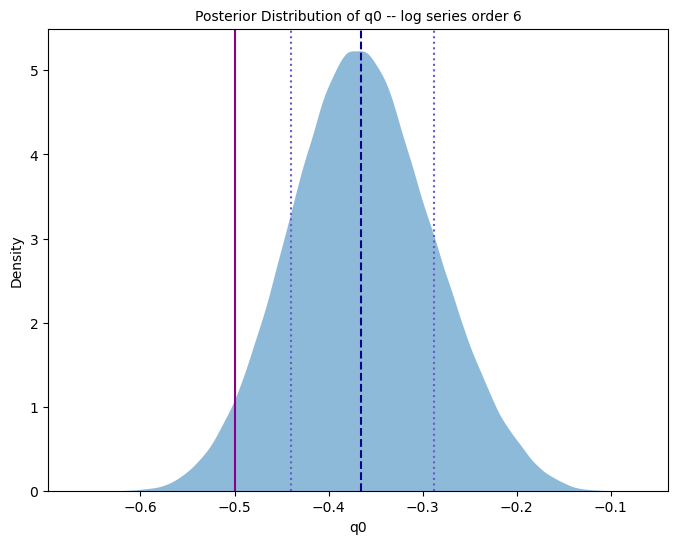

In [47]:
# FIXED H0

# Log series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [3,4,5,6]    # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_log = []
tau_log = []
sampler_order_log = []
samples_order_log = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 30000 * (orderd-1)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.8), (WalkMove(), 0.2)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, log_series, np.log(1+zd), datad, orderd), pool=pool, moves = moves)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_log.append(np.mean(sampler.acceptance_fraction))   
    tau_log.append(sampler.get_autocorr_time())
    sampler_order_log.append(sampler)
    samples_order_log.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_log_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- log series order {orderd}', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_log_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()


file_path = os.path.join(directory, "sampler_log.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_order_log, f)

In [ ]:
# z series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [2,3,4,5,6]    # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_z = []
tau_z = []
sampler_order_z = []
samples_order_z = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 30000 * (orderd-1)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.8), (WalkMove(), 0.2)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, z_series, zd, datad, orderd), pool=pool, moves=moves)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_z.append(np.mean(sampler.acceptance_fraction))   
    tau_z.append(sampler.get_autocorr_time())
    sampler_order_z.append(sampler)
    samples_order_z.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_z_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- z series order {orderd}', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_z_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()

file_path = os.path.join(directory, "sampler_z.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_order_z, f)

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_139244/743836323.py:53: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
  0%|                                                 | 0/30000 [00:00<?, ?it/s]/home/jessica/miniconda3/envs/py3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████| 30000/30000 [05:25<00:00, 92.20it/s]
/home/jessica/miniconda3/envs/py3/lib/python3.12/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


<IPython.core.display.Math object>

  0%|                                                 | 0/60000 [00:00<?, ?it/s]/home/jessica/miniconda3/envs/py3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████| 60000/60000 [25:20<00:00, 39.45it/s]
/home/jessica/miniconda3/envs/py3/lib/python3.12/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  0%|                                                | 0/150000 [00:00<?, ?it/s]/home/jessica/miniconda3/envs/py3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
 45%|████████████████▎                   | 67900/150000 [37:44<41:52, 32.67it/s]

In [ ]:
# y series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [3]    # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_y = []
tau_y = []
sampler_order_y = []
samples_order_y = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 30000 * (orderd-1)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.9), (WalkMove(), 0.1)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, y_series, zd, datad, orderd), moves = moves, pool=pool, live_dangerously=True)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_y.append(np.mean(sampler.acceptance_fraction))   
    tau_y.append(sampler.get_autocorr_time())
    sampler_order_y.append(sampler)
    samples_order_y.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_y_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- y series order {orderd}', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_y_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()

file_path = os.path.join(directory, "sampler_y.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_order_y, f)

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_304686/4134132341.py:53: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
100%|███████████████████████████████████| 120000/120000 [36:20<00:00, 55.04it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

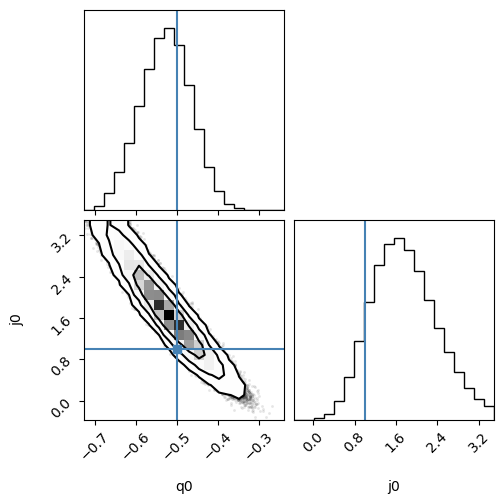

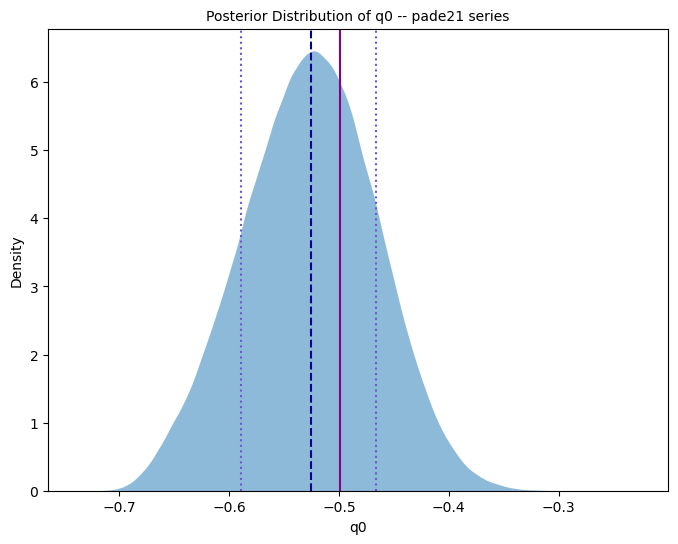

In [10]:
# Pade 21 series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [3]#2,3,4,5,6]    # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_pade21 = []
tau_pade21 = []
sampler_pade21 = []
samples_pade21 = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 40000 * (orderd)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.8), (WalkMove(), 0.2)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, dLpade21, zd, datad, orderd), pool=pool, moves=moves)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_pade21.append(np.mean(sampler.acceptance_fraction))   
    tau_pade21.append(sampler.get_autocorr_time())
    sampler_pade21.append(sampler)
    samples_pade21.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_pade21_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- pade21 series', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_pade21_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()

file_path = os.path.join(directory, "sampler_pade21.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_pade21, f)

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_304686/3360142537.py:53: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
100%|█████████████████████████████████████| 90000/90000 [29:04<00:00, 51.59it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

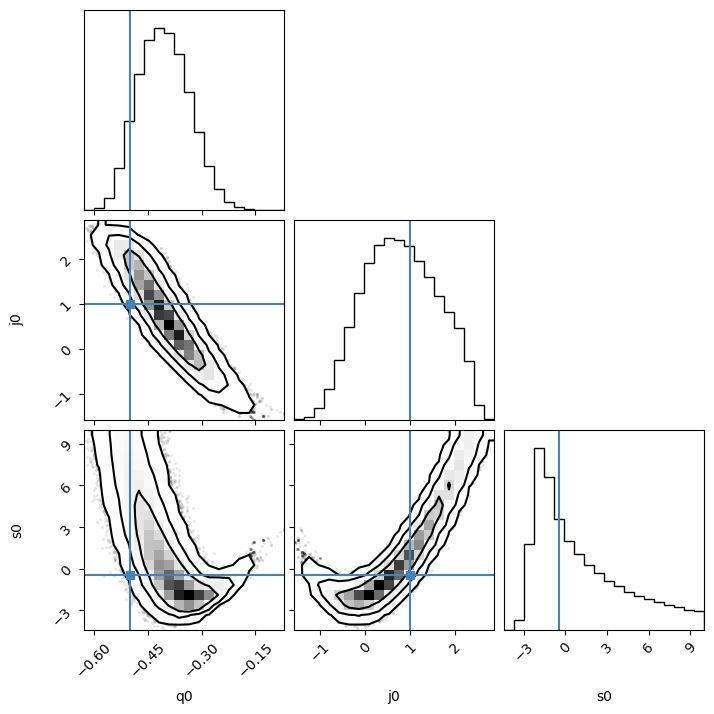

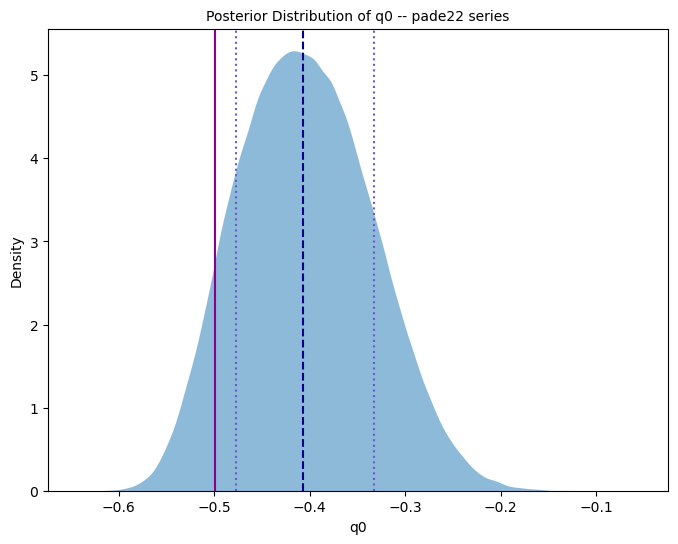

In [11]:
# Pade 22 series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [4]    # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_pade22 = []
tau_pade22 = []
sampler_pade22 = []
samples_pade22 = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 30000 * (orderd-1)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.8), (WalkMove(), 0.2)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, dLpade22, zd, datad, orderd), pool=pool, moves=moves)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_pade22.append(np.mean(sampler.acceptance_fraction))   
    tau_pade22.append(sampler.get_autocorr_time())
    sampler_pade22.append(sampler)
    samples_pade22.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_pade22_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- pade22 series', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_pade22_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()

file_path = os.path.join(directory, "sampler_pade22.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_pade22, f)

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_304686/944689887.py:53: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
100%|███████████████████████████████████| 120000/120000 [33:16<00:00, 60.10it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

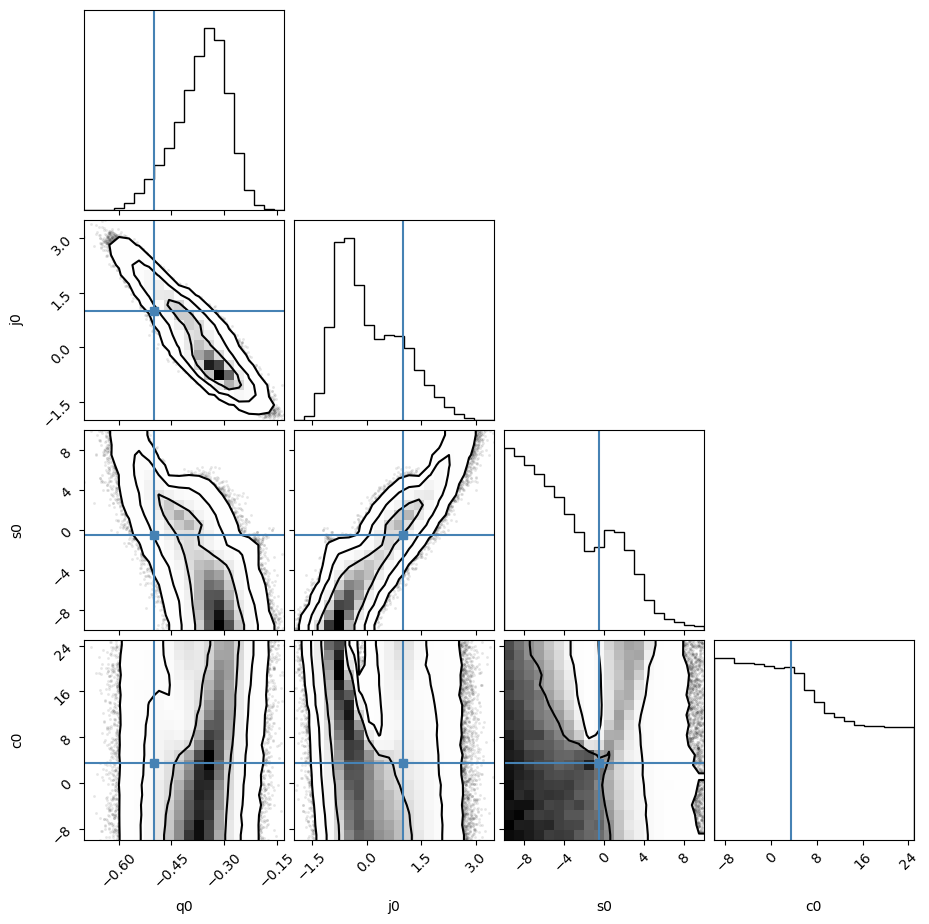

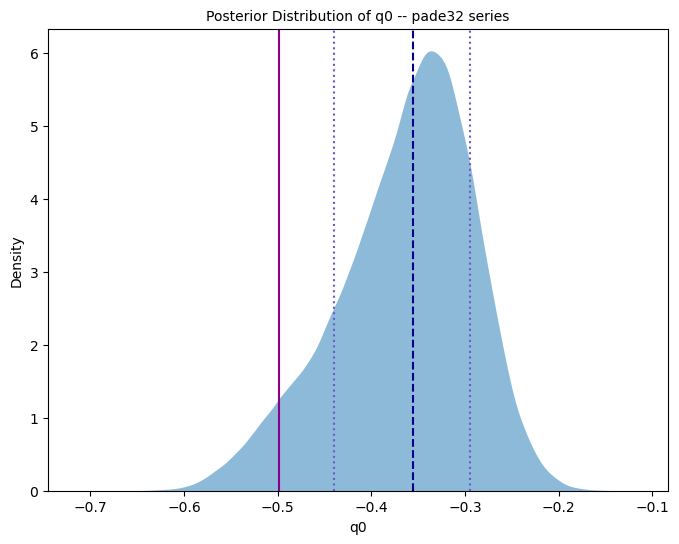

In [12]:
# Pade 32 series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [5]#2,3,4,5,6]    # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_pade32 = []
tau_pade32 = []
sampler_pade32 = []
samples_pade32 = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 30000 * (orderd-1)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.8), (WalkMove(), 0.2)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, dLpade32, zd, datad, orderd), pool=pool, moves=moves)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_pade32.append(np.mean(sampler.acceptance_fraction))   
    tau_pade32.append(sampler.get_autocorr_time())
    sampler_pade32.append(sampler)
    samples_pade32.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_pade32_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- pade32 series', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_pade32_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()

file_path = os.path.join(directory, "sampler_pade32.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_pade32, f)

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_304686/1427705539.py:53: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
100%|███████████████████████████████████| 120000/120000 [54:17<00:00, 36.84it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

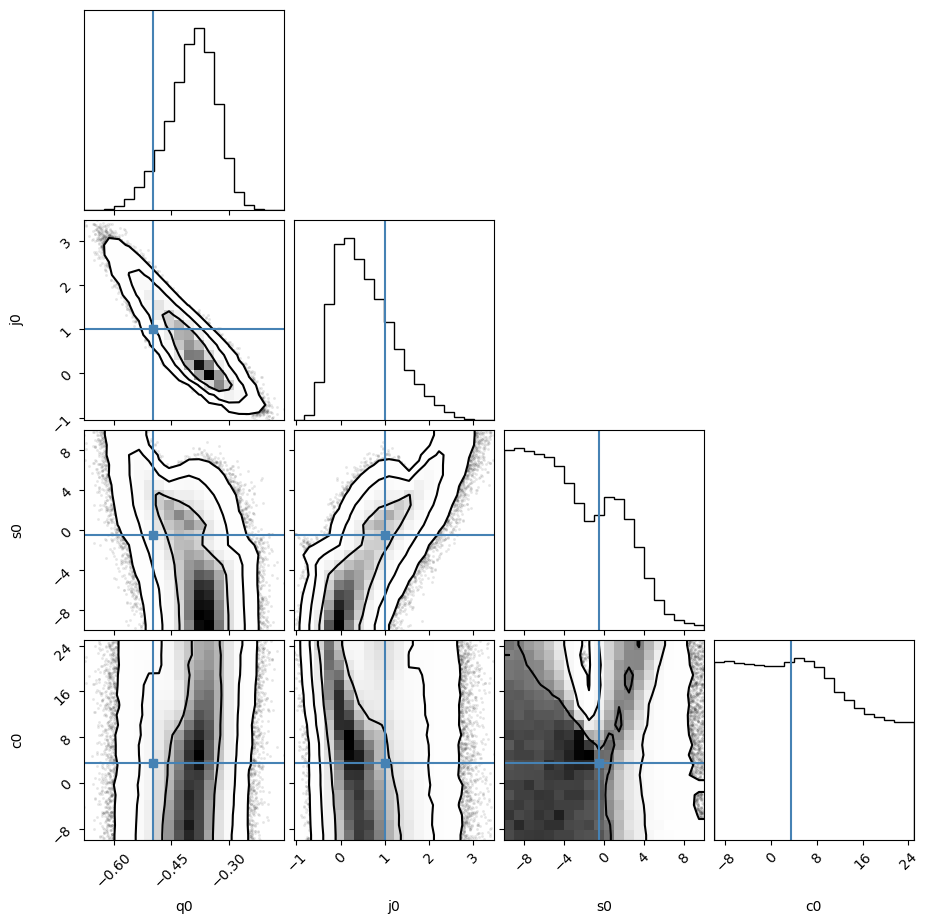

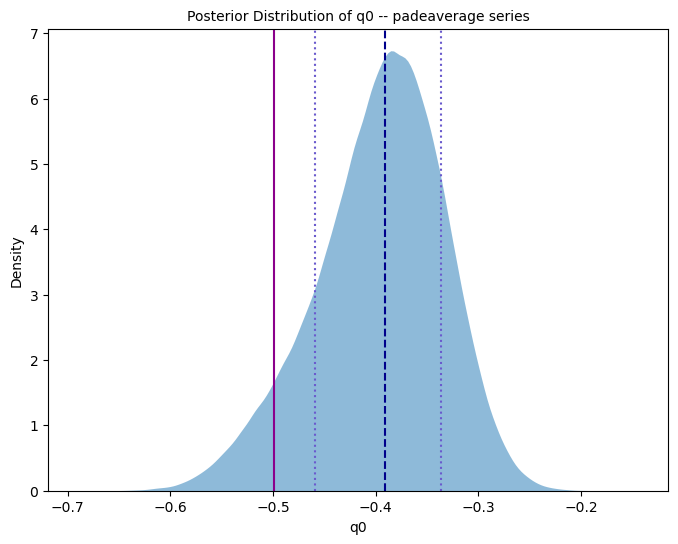

In [13]:
# Pade average series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [5]   # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_padeav = []
tau_padeav = []
sampler_padeav = []
samples_padeav = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 30000 * (orderd-1)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.8), (WalkMove(), 0.2)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, dLpadeaverage, zd, datad, orderd), pool=pool, moves=moves)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_padeav.append(np.mean(sampler.acceptance_fraction))   
    tau_padeav.append(sampler.get_autocorr_time())
    sampler_padeav.append(sampler)
    samples_padeav.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_padeav_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- padeaverage series', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_padeav_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()

file_path = os.path.join(directory, "sampler_padeav.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_padeav, f)

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_304686/2628328193.py:53: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
100%|█████████████████████████████████| 150000/150000 [3:16:27<00:00, 12.73it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

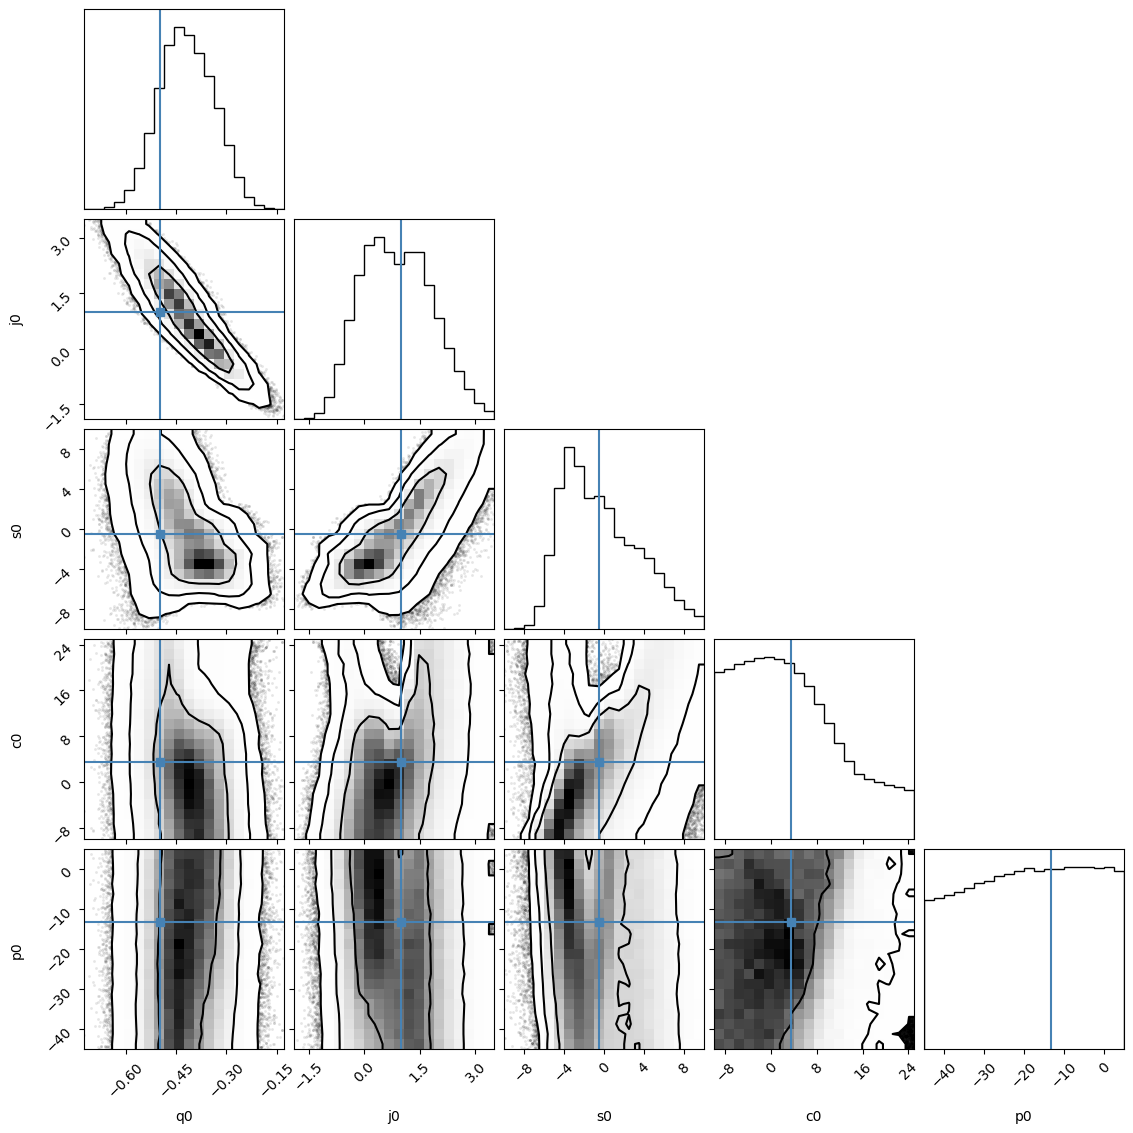

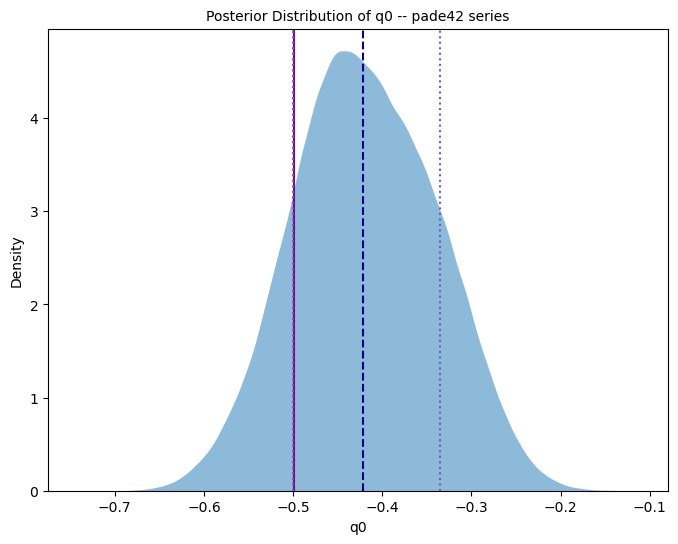

In [14]:
# Pade 42 series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [6]    # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_pade42 = []
tau_pade42 = []
sampler_pade42 = []
samples_pade42 = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 30000 * (orderd-1)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.8), (WalkMove(), 0.2)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, dLpade42, zd, datad, orderd), pool=pool, moves=moves)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_pade42.append(np.mean(sampler.acceptance_fraction))   
    tau_pade42.append(sampler.get_autocorr_time())
    sampler_pade42.append(sampler)
    samples_pade42.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_pade42_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- pade42 series', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_pade42_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()

file_path = os.path.join(directory, "sampler_pade42.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_pade42, f)

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_304686/1128986045.py:53: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
100%|█████████████████████████████████| 150000/150000 [1:41:27<00:00, 24.64it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

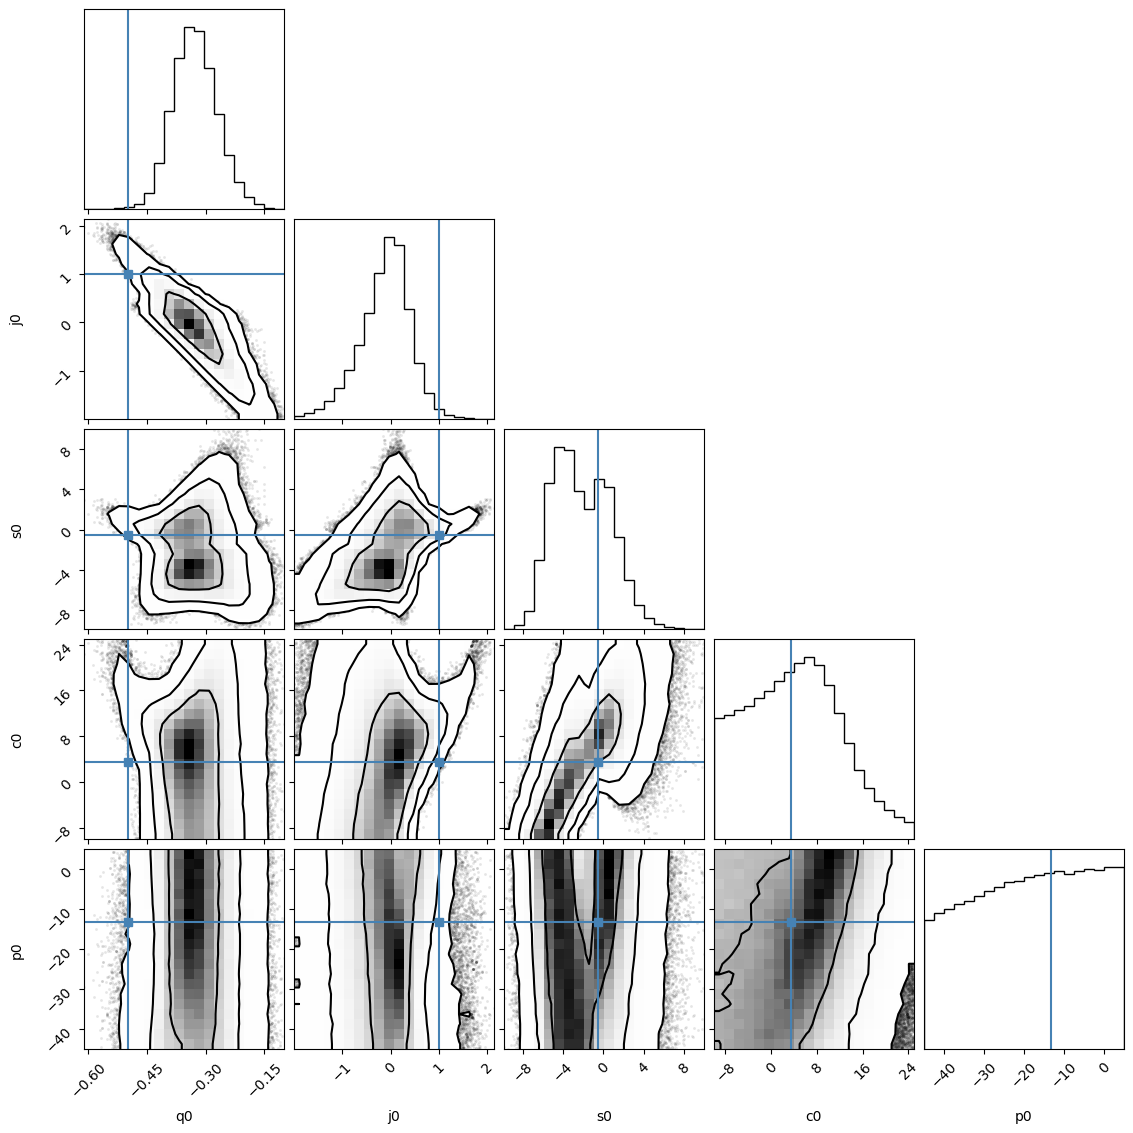

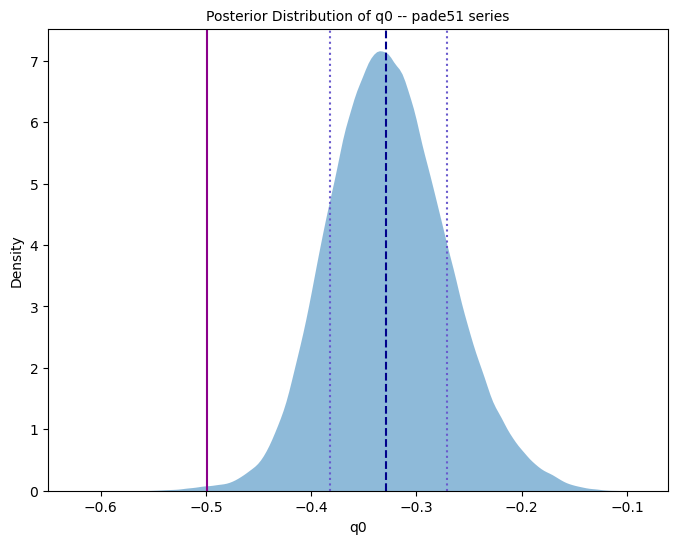

In [15]:
# Pade 51 series
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
order_list = [6]    # The order of the cosmographic expansion, or another integer value
initial_t = np.array([-0.4, 1, -0.4, 5, -13])

acceptance_pade51 = []
tau_pade51 = []
sampler_pade51 = []
samples_pade51 = []
H0 = 73.5

for i in range(len(order_list)):
# Initial guess for the parameters
    orderd = order_list[i]
    initial = initial_t[:(orderd-1)]

    # Number of walkers (independent chains) and steps
    nwalkers = 40
    ndim = len(initial)  # 3 parameters (a, b, c)
    nsteps = 30000 * (orderd-1)

    # Initialize the walkers around the initial guess
    pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


    # Initialize the MCMC sampler
    with Pool() as pool:
        moves = [(StretchMove(a=1.5), 0.8), (WalkMove(), 0.2)]  # 90% StretchMove, 10% WalkMove
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(H0, dLpade51, zd, datad, orderd), pool=pool, moves=moves)
        sampler.run_mcmc(pr, nsteps, progress=True)
    
    acceptance_pade51.append(np.mean(sampler.acceptance_fraction))   
    tau_pade51.append(sampler.get_autocorr_time())
    sampler_pade51.append(sampler)
    samples_pade51.append(sampler.get_chain(discard=0, thin=10, flat=True))

    samples = sampler.get_chain(discard=500, thin=10, flat=True)
    
    # Plot the results using a corner plot
    
    labelsdt = ["q0", "j0", "s0", "c0", "p0"]
    labelsd = labelsdt[:(orderd-1)]
    fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:(orderd-1)], levels = (0.68,0.95,0.997))
    filename = f'MCMC_pade51_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()
    
    for i in range(ndim):
        mcmc = np.percentile(samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
        display(Math(txt))

    # Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
    q0_samples = samples[:, 0]  # Extracting the second parameter (q0)
    
    # Calculate the 1-sigma confidence interval (68% confidence)
    q0_median = np.median(q0_samples)
    q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
    q0_err_lower = q0_median - q0_16th
    q0_err_upper = q0_84th - q0_median
    
    # Plot the histogram with KDE
    plt.figure(figsize=(8, 6))
    #sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
    sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)
    
    # Plot the true value of q0
    plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')
    
    # Plot the median value and 1-sigma range
    plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
    plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
    plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')
    
    # Labeling the plot
    plt.xlabel('q0', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.title(f'Posterior Distribution of q0 -- pade51 series', fontsize=10)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    
    # Show the plot
    filename = f'Posterior_q0_pade51_series_{orderd}order.png'
    file_path = os.path.join(directory, filename)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')
    #plt.show()

file_path = os.path.join(directory, "sampler_pade51.pkl")  # Combine directory and file name

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the list of samplers
with open(file_path, "wb") as f:  # Correct the mode to "wb" for binary write
    dill.dump(sampler_pade51, f)

In [204]:
# Load the list of samplers
with open("sampler_order.pkl", "rb") as f:
    samplerss = dill.load(f)

# extra

In [179]:
# Define z, data, and order beforehand
zd = z_pantheon       # The redshift array
datad = dl_pantheon_mock    # The observed data (e.g., dL_obs or other data)
orderd = 2     # The order of the cosmographic expansion, or another integer value

# Initial guess for the parameters
initial_t = np.array([70, -0.4, 0.9, 1, 7, -13])
initial = initial_t[:orderd]

# Number of walkers (independent chains) and steps
nwalkers = 32
ndim = len(initial)  # 3 parameters (a, b, c)
nsteps = 20000

# Initialize the walkers around the initial guess
pr = [initial + 0.0001 * np.random.randn(ndim) for i in range(nwalkers)] #initial + 1e-3 * np.random.randn(nwalkers, ndim)


# Initialize the MCMC sampler
with Pool() as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(log_series, np.log(1+zd), datad, orderd), pool=pool)
    sampler.run_mcmc(pr, nsteps, progress=True)
print("Mean acceptance rate is: {0:1.2f}".format(np.mean(sampler.acceptance_fraction)))    

100%|████████████████████████████████████| 20000/20000 [01:52<00:00, 178.43it/s]


Mean acceptance rate is: 0.00


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13074/361351715.py:16: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"


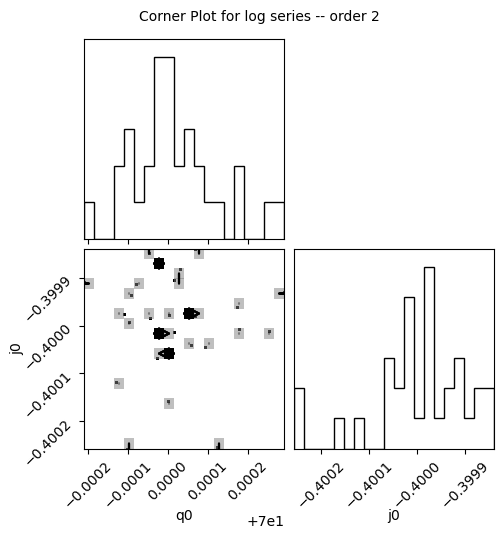

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [192]:
# Get the samples
samples = sampler_order[0].get_chain(discard=500, thin=10, flat=True)#sampler.get_chain(discard=500, thin=10, flat=True)
orderd = order_list[0]
# Plot the results using a corner plot

labelsdt = ["q0", "j0", "s0", "c0", "p0"]
labelsd = labelsdt[:orderd]
fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:orderd], levels = (0.68,0.95,0.997))
fig.suptitle(f'Corner Plot for log series -- order {orderd}', fontsize=10)
#plt.legend(fontsize=12)
plt.show()

for i in range(orderd):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
    display(Math(txt))

In [174]:
# # Get the samples
# samples = sampler.get_chain(discard=500, thin=10, flat=True)

# plt.plot(samples[:,1])

# # Plot the results using a corner plot

# labelsdt = ["H0", "q0", "j0", "s0", "c0", "p0"]
# labelsd = labelsdt[:orderd]
# fig = corner.corner(samples, summary=True, labels=labelsd, truths=thetat[:orderd], levels = (0.68,0.95,0.997))
# plt.title(f'Corner Plot for log series -- order {orderd}', fontsize=16)
# plt.legend(fontsize=12)
# plt.grid(True)

# plt.show()

# for i in range(ndim):
#     mcmc = np.percentile(samples[:, i], [16, 50, 84])
#     q = np.diff(mcmc)
#     txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
#     txt = txt.format(mcmc[1], q[0], q[1], labelsd[i])
#     display(Math(txt))

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13074/1409089067.py:12: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"


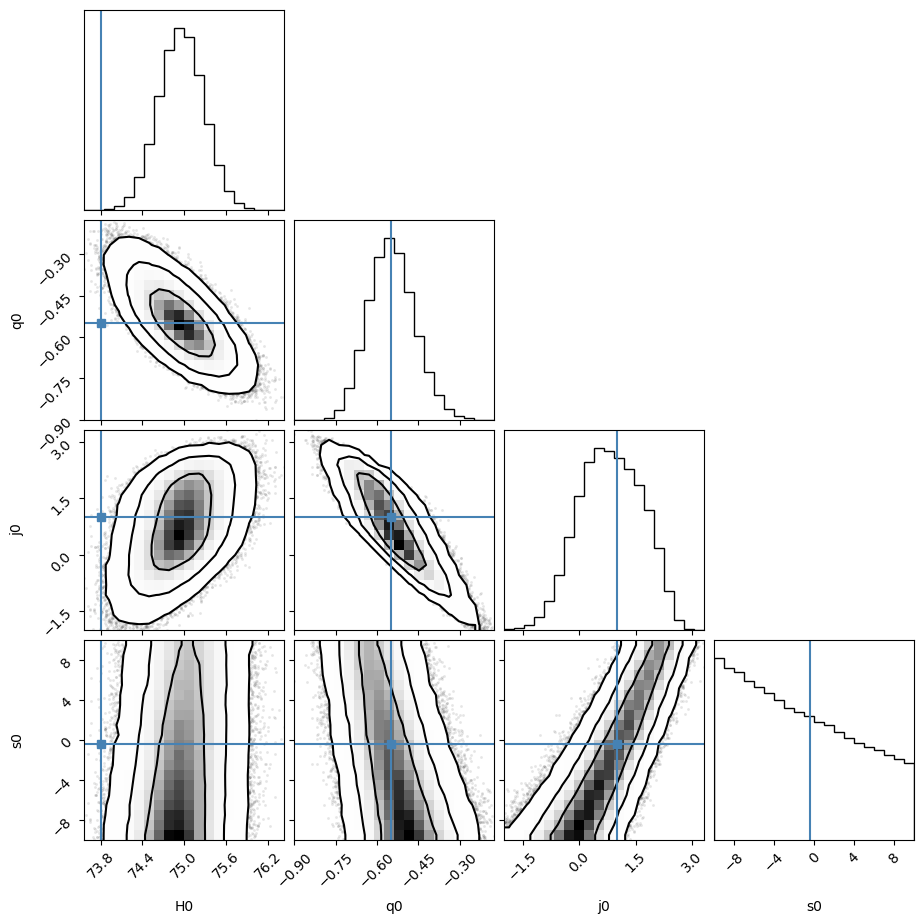

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

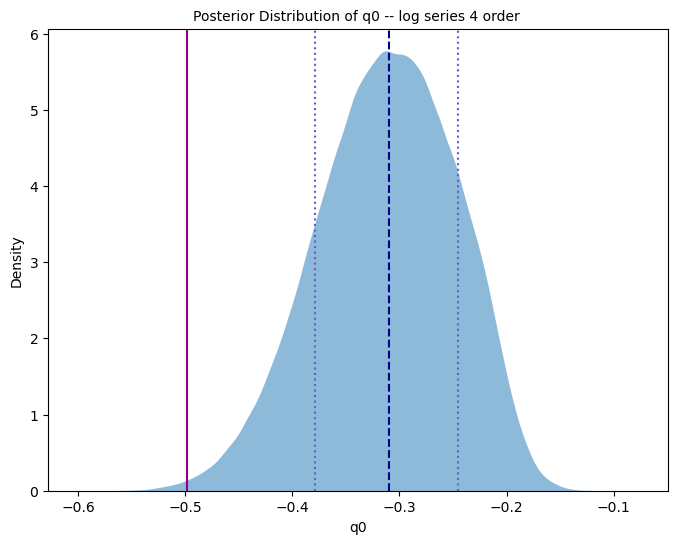

In [176]:
# Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
q0_samples = samples[:, 0]  # Extracting the second parameter (q0)

# Calculate the 1-sigma confidence interval (68% confidence)
q0_median = np.median(q0_samples)
q0_16th, q0_84th = np.percentile(q0_samples, [16, 84])
q0_err_lower = q0_median - q0_16th
q0_err_upper = q0_84th - q0_median

# Plot the histogram with KDE
plt.figure(figsize=(8, 6))
#sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
sns.kdeplot(q0_samples, fill=True, alpha=.5, linewidth=0)

# Plot the true value of q0
plt.axvline(q0t, color='darkmagenta', linestyle='-', label=f'True q0 = {q0t:.2f}')

# Plot the median value and 1-sigma range
plt.axvline(q0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
plt.axvline(q0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
plt.axvline(q0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')



# Labeling the plot
plt.xlabel('q0', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.title(f'Posterior Distribution of q0 -- log series {orderd} order ', fontsize=10)
#plt.legend(fontsize=12)
#plt.grid(True)

# Show the plot
plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()


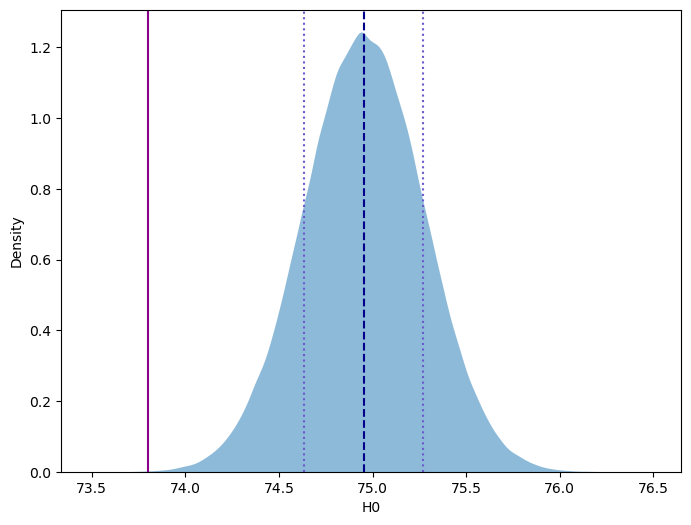

In [152]:
# Assuming `samples` is the MCMC chain with shape (nsteps * nwalkers, ndim)
H0_samples = samples[:, 0]  # Extracting the second parameter (q0)

# Calculate the 1-sigma confidence interval (68% confidence)
H0_median = np.median(H0_samples)
H0_16th, H0_84th = np.percentile(H0_samples, [16, 84])
H0_err_lower = H0_median - H0_16th
H0_err_upper = H0_84th - H0_median

# Plot the histogram with KDE
plt.figure(figsize=(8, 6))
#sns.histplot(q0_samples, kde=True, , bins=30, color='blue')
sns.kdeplot(H0_samples, fill=True, alpha=.5, linewidth=0)

# Plot the true value of q0
plt.axvline(H0t, color='darkmagenta', linestyle='-', label=f'True q0 = {H0t:.2f}')

# Plot the median value and 1-sigma range
plt.axvline(H0_median, color='darkblue', linestyle='--')#, label=f'Median q0 = {q0_median:.2f}')
plt.axvline(H0_16th, color='slateblue', linestyle=':')#, label=f'1-sigma lower = {q0_16th:.2f}')
plt.axvline(H0_84th, color='slateblue', linestyle=':')#, label=f'1-sigma upper = {q0_84th:.2f}')



# Labeling the plot
plt.xlabel('H0', fontsize=10)
plt.ylabel('Density', fontsize=10)
#plt.title('Posterior Distribution of q0 with 1-Sigma Error and True Value', fontsize=16)
#plt.legend(fontsize=12)
#plt.grid(True)

# Show the plot
plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()